In [3]:
import numpy as np
import itertools

# Cosmetics:
import matplotlib.pyplot as plt

import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

In [4]:
# Make fake data grid of d0 vs pT generated as the product of d0 and ET efficiencies
d0Effs = np.array([(250.,0.075),(175.,0.25),(125.,0.36),(90.,0.47),(75.,0.5),(65.,0.55),(55.,0.55),(45.,0.58),(35.,0.58),(25.,0.64),(15.,0.76),(5.,0.8)],dtype=np.dtype([('d0', float), ('Efficiency', float)]))
d0Effs.sort(order='d0')
pTEffs = np.array([(5,0.98,0.79,0.58),(7,0.93,0.8,0.6),(9,0.88,0.81,0.67),(12,0.81,0.82,0.66),(16,0.83,0.75,0.65),(20,0.86,0.79,0.68),(24,0.88,0.82,0.71),(28,0.89,0.84,0.74),(32,0.9,0.85,0.75),(38,0.92,0.87,0.77),(44,0.93,0.88,0.79),(50,0.935,0.89,0.81),(56,0.94,0.895,0.815),(65,0.942,0.915,0.85),(80,0.943,0.915,0.855),(115,0.945,0.93,0.885)],dtype=np.dtype([('ET', float), ('Loose', float), ('Medium', float),('Tight', float)]))
pTEffs.sort(order='ET')

In [5]:
from scipy.interpolate import interp1d
d0Interp = interp1d(d0Effs['d0'], d0Effs['Efficiency'], kind='linear', fill_value='extrapolate', bounds_error=False)
pTInterp = interp1d(pTEffs['ET'], pTEffs['Tight'], kind='linear', fill_value=(0.0,pTEffs['Tight'][-1]), bounds_error=False)

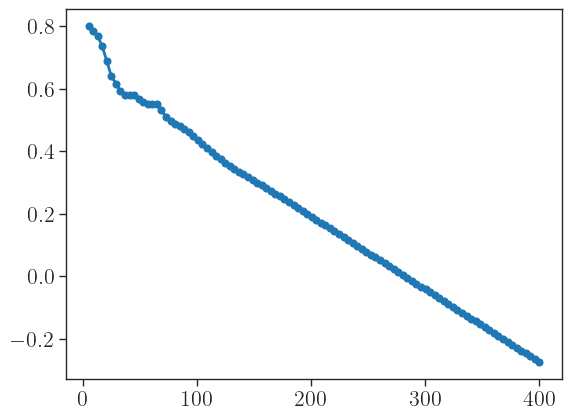

In [6]:
d0list = np.linspace(5.,400.,100)
y = [d0Interp(d0) for d0 in d0list]
plt.plot(d0list,y,label='d0 efficiency (interp)',linewidth=2,marker='o')
# plt.xlim(5.,400.)
# plt.ylim(-10,1)
plt.show()

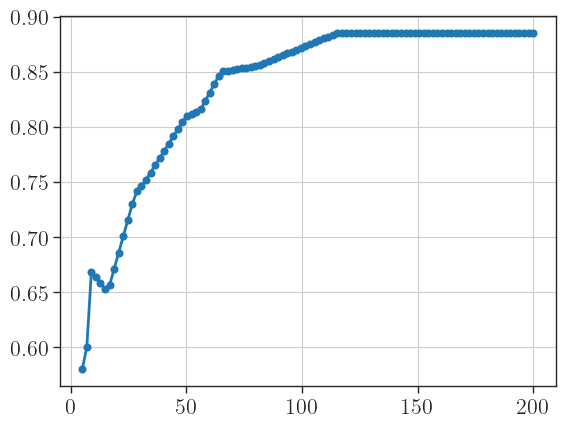

In [7]:
ptlist = np.linspace(5.,200.,100)
y = [pTInterp(pt) for pt in ptlist]
plt.plot(ptlist,y,label='pT efficiency (interp)',linewidth=2,marker='o')
plt.grid()
plt.show()

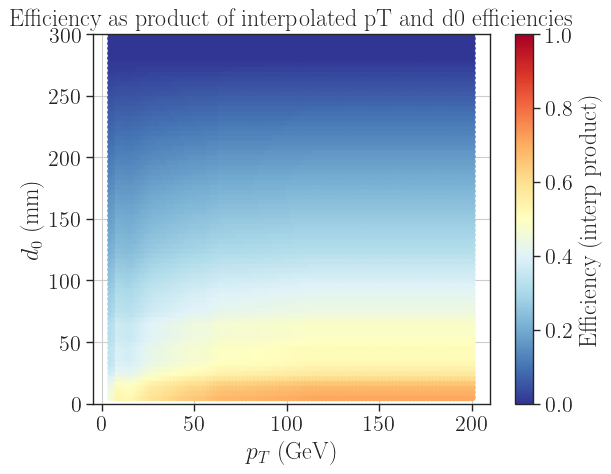

In [8]:
x  = []
y = []
z = []
for pt,d0 in itertools.product(ptlist, d0list):
    eff = pTInterp(pt)*d0Interp(d0)
    x.append(pt)
    y.append(d0)
    z.append(eff)

plt.scatter(x,y,c=z, cmap=cm_rev, vmin=0.0, vmax=1.0)
plt.colorbar(label='Efficiency (interp product)')
plt.xlabel(r'$p_T$ (GeV)')
plt.ylabel(r'$d_0$ (mm)')
plt.title('Efficiency as product of interpolated pT and d0 efficiencies')
plt.ylim(0,300.0)
plt.grid()
plt.show()

### Generate data for the 2D effs

In [ ]:
# x  = []
# y = []
# z = []
# ptlist = np.linspace(65.,200.,30).tolist() + np.linspace(210.,1000.,30).tolist()
# d0list = np.linspace(3.,300.,50).tolist()
# for pt,d0 in itertools.product(ptlist, d0list):
#     eff = pTInterp(pt)*d0Interp(d0)
#     x.append(pt)
#     y.append(d0)
#     z.append(max(0.,eff))
# np.savetxt('recoEffs_from_1Deffs.csv', np.array([x,y,z]).T, delimiter=',', header=r'Lepton $p_\text{T}$ [GeV],Lepton $d_0$ [mm],Efficiency', comments='# Efficiencies generated as product of interpolated 1D efficiencies for d0 and pT from Fig1. in https://arxiv.org/pdf/2011.07812 and Fig.17 in https://arxiv.org/pdf/1908.00005, respectively.\n', fmt='%.3e')

## Compare with binned ATLAS efficiency

In [13]:
csv_path = 'HEPData-ins1831504-v2-csv/pt-d0electronefficiency.csv'
with open(csv_path, 'r') as f:
      lines = [l for l in f.readlines() if not l.startswith('#')]
data = np.genfromtxt(lines, delimiter=",", comments="#",
                        names=True,   dtype=float)
print(data.dtype.names)

('Lepton_p_textT_GeV', 'Lepton_d_0_mm', 'Efficiency')


In [15]:
points = []
for pt in data:
    eff_ATLAS = pt['Efficiency']
    eff_interp = pTInterp(pt['Lepton_p_textT_GeV'])*d0Interp(pt['Lepton_d_0_mm'])
    points.append((pt['Lepton_p_textT_GeV'], pt['Lepton_d_0_mm'], eff_ATLAS, eff_interp))
points = np.array(points, dtype=np.dtype([('pT', float), ('d0', float), ('Efficiency_ATLAS', float), ('Efficiency_interp', float)]))

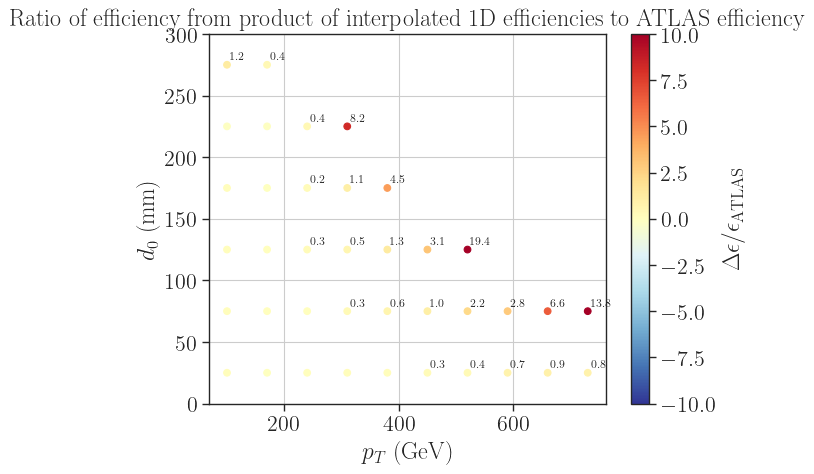

In [26]:

x = points['pT']
y = points['d0']
z = points['Efficiency_interp'] / points['Efficiency_ATLAS'] -1.0

plt.scatter(x,y, c=z, cmap=cm_rev, vmin=-10.0, vmax=10.0)
for xi, yi, zi in zip(x, y, z):
    if abs(zi) < 0.15: 
        continue
    plt.annotate(f'{zi:.1f}', (xi, yi), 
                 textcoords='offset points', xytext=(2, 4), fontsize=8, rotation=0)
plt.colorbar(label=r'$\Delta \epsilon / \epsilon_{\rm ATLAS}$')
plt.xlabel(r'$p_T$ (GeV)')
plt.ylabel(r'$d_0$ (mm)')
plt.title('Ratio of efficiency from product of interpolated 1D efficiencies to ATLAS efficiency')
plt.ylim(0,300.0)
plt.grid()
plt.show()